In [1]:
import os
os.chdir('c:\\Users\\Mikael Huff\\Documents\\Training')
os.getcwd()

'c:\\Users\\Mikael Huff\\Documents\\Training'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
def softmax(H):
    return (np.exp(H.T)/np.sum(np.exp(H),axis=1)).T 

def cat_cross_entropy(Y, P_hat):
    return -(1/len(Y))*np.sum(Y*np.log(P_hat))

def indices_to_one_hot(data, nb_classes):
    targets = np.array(data).reshape(-1)
    return np.eye(nb_classes)[targets]

def accuracy(y, y_hat):
    return np.mean(y==y_hat)

In [5]:
data = pd.read_csv('data/TripGaussKNN.csv')

In [6]:
y = data['2'].to_numpy()
X = data[['0','1']].to_numpy()

### MV Logistic Class

In [ ]:
class MVLogisticRegression():

    def fit(self, X, y, alpha=1e-3, epochs=1e3, show_curve=True):
        epochs = int(epochs)
        N, d = X.shape
        K = len(np.unique(y))
        Y = indices_to_one_hot(y, K)

        # Initialize Weights and Biases
        self.W = np.random.randn(d,K)
        self.B = np.random.randn(K)

        # Loss Container
        L = np.zeros(epochs)

        # Gradient Descent
        for epoch in range(epochs):
            P_hat = self.__forward__(X)
            L[epoch] = cat_cross_entropy(Y, P_hat)

            # Weight and Bias Updates
            self.W -= alpha * (1/N) * X.T @ (P_hat-Y)
            self.B -= alpha * (1/N) * np.sum(P_hat-Y,axis=0)
           

        if show_curve:
            plt.figure()
            plt.plot(L)
            plt.xlabel('epochs')
            plt.ylabel('$\\mathcal{L}$')
            plt.title('Training Curve')
            plt.show()

    def __forward__(self, X):
        # return X @ self.W + self.B
        return softmax(X@self.W + self.B)

    def predict(self, X):
        return np.argmax(self.__forward__(X), axis=1)

### Implementation of MVLogisticRegression Class

C:\Users\Mikael Huff\AppData\Local\Temp\ipykernel_13388\2547011805.py:5: RuntimeWarning: invalid value encountered in log
  return -(1/len(Y))*np.sum(Y*np.log(P_hat))


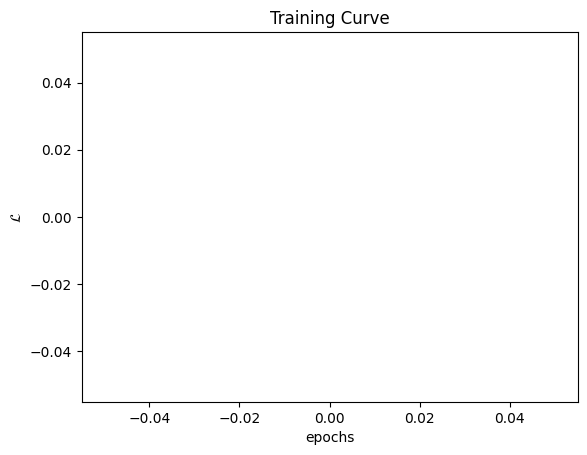

In [22]:
mv_logreg = MVLogisticRegression()
mv_logreg.fit(X, y, alpha=5e-3, epochs=5e3)

In [20]:

y_hat = mv_logreg.predict(X)
accuracy(y,y_hat)

np.float64(0.968)